# Practice Lab A: Systems of Equations from Word Problems

**Area:** linear-algebra · **Related lessons/concepts:** L08–L12; Quiz 02; Homework 02

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. A market problem (Grade 9 style)
On day 1, 2 mangoes and 3 bananas cost 7 thousand riel; on day 2, 4 mangoes and 1 banana cost 9 thousand riel. Find each price.

In [2]:
A=np.array([[2,3],[4,1]],float); b=np.array([7,9],float)
print("solve:",np.linalg.solve(A,b))
# elimination by hand: R2 - 2 R1
E=A.copy(); E[1]-=2*E[0]; print(E, b[1]-2*b[0])

solve: [2. 1.]
[[ 2.  3.]
 [ 0. -5.]] -5.0


## 2. Draw it: where do the lines cross?

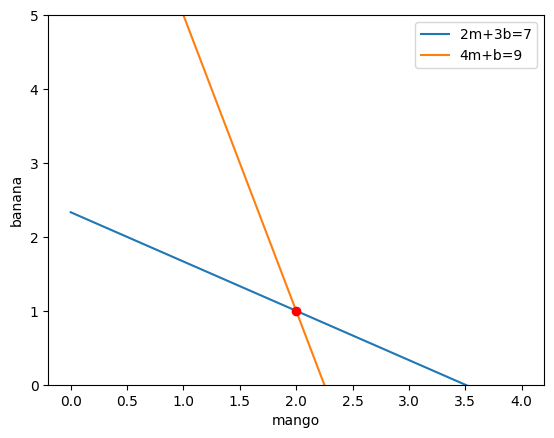

In [3]:
x=np.linspace(0,4,100)
plt.plot(x,(7-2*x)/3,label="2m+3b=7"); plt.plot(x,9-4*x,label="4m+b=9")
s=np.linalg.solve(A,b); plt.scatter(*s,c='r',zorder=3); plt.xlabel('mango'); plt.ylabel('banana'); plt.legend(); plt.ylim(0,5); plt.show()

## 3. Classify many systems automatically

In [4]:
def classify(A,b):
    A=np.array(A,float); b=np.array(b,float)
    rA=np.linalg.matrix_rank(A); rAb=np.linalg.matrix_rank(np.c_[A,b])
    return "none" if rA<rAb else ("unique" if rA==A.shape[1] else "infinite")
cases={"day-shop":([[2,3],[4,1]],[7,9]),"same price list":([[1,1],[2,2]],[10,20]),"inconsistent":([[1,1],[2,2]],[10,24]),
       "3 unknowns":([[1,1,1],[1,2,1],[1,1,2]],[10,15,12]),"3 dependent":([[1,1,1],[2,2,2],[3,3,3]],[10,20,30])}
for k,(A_,b_) in cases.items(): print(f"{k:16s} det/rank:",np.round(np.linalg.det(np.array(A_,float)),3) if len(A_)==len(A_[0]) else '-',np.linalg.matrix_rank(np.array(A_,float)),"->",classify(A_,b_))

day-shop         det/rank: -10.0 2 -> unique
same price list  det/rank: 0.0 1 -> infinite
inconsistent     det/rank: 0.0 1 -> none
3 unknowns       det/rank: 1.0 3 -> unique
3 dependent      det/rank: 0.0 1 -> infinite


## 4. Does the price of the constants matter? (No – only A decides singularity)

In [5]:
A3=np.array([[1,1,1],[1,1,2],[1,1,3]],float)
for rhs in ([10,15,20],[10,15,18],[0,0,0]): print(rhs, classify(A3,rhs))

[10, 15, 20] infinite
[10, 15, 18] none
[0, 0, 0] infinite


## 5. Timing: Cramer vs elimination

In [6]:
import time
def cramer(A,b):
    D=np.linalg.det(A); return np.array([np.linalg.det(np.c_[A[:,:j],b,A[:,j+1:]])/D for j in range(len(b))])
for n in (3,6,9):
    A_=np.random.default_rng(0).normal(size=(n,n)); b_=np.ones(n)
    t=time.time(); cramer(A_,b_); t1=time.time()-t; t=time.time(); np.linalg.solve(A_,b_); t2=time.time()-t
    print(n, np.allclose(cramer(A_,b_),np.linalg.solve(A_,b_)), f"cramer {t1:.5f}s solve {t2:.5f}s")

3 True cramer 0.00006s solve 0.00001s
6 True cramer 0.00007s solve 0.00001s
9 True cramer 0.00009s solve 0.00001s


## Exercises

**Exercise 1.** Write your own word problem (three unknowns) and solve it. Check by substitution.

In [7]:
# your code here

**Exercise 2.** Make a 3x3 system that has infinitely many solutions and show rank < 3 but rank(A|b)=rank(A).

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
A=np.array([[1,1,1],[1,2,3],[2,1,1]],float); b=np.array([6,14,7],float); s=np.linalg.solve(A,b); print(s); assert np.allclose(A@s,b)

[1. 2. 3.]


In [10]:
# Solution 2
A=np.array([[1,1,1],[1,1,1],[1,2,3]],float); b=np.array([6,6,14],float); assert classify(A,b)=='infinite'